# BoxComm data visualization

This notebook shows how to inspect one released evaluation sample:

- load video
- decode frame
- load the paired skeleton/event assets
- overlay red/blue skeletons on the frame using the HMR-pipeline coordinate convention
- inspect the first 10 commentary sentences
- inspect the first 10 punch events


In [1]:
from pathlib import Path
import json
import pickle

import cv2
import matplotlib.pyplot as plt
import numpy as np

VIDEO_ID = 478
VIDEO_STEM = "478_LUTSAIKHAN-Altantsetseg_MINAKSHI-Minakshi"
FRAME_INDEX = 200

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
data_root = repo_root / "data" / "eval"

video_path = data_root / "videos" / f"{VIDEO_STEM}.mp4"
sample_frame_path = data_root / "sample_frames" / "478_frame200.png"
event_dir = data_root / "events" / VIDEO_STEM
event_json_path = event_dir / "video_event_inference_3.json"
skeleton_path = event_dir / f"{VIDEO_STEM}_chmr_phalp_p2d_uve.pkl"
asr_path = data_root / "asr" / f"{VIDEO_ID}.json"

print("repo_root:", repo_root)
print("video_path:", video_path)
print("event_json_path:", event_json_path)
print("skeleton_path:", skeleton_path)
print("asr_path:", asr_path)
print("sample_frame_path:", sample_frame_path)


repo_root: /mnt/nfs_share/wangkw/BoxComm
video_path: /mnt/nfs_share/wangkw/BoxComm/data/eval/videos/478_LUTSAIKHAN-Altantsetseg_MINAKSHI-Minakshi.mp4
event_json_path: /mnt/nfs_share/wangkw/BoxComm/data/eval/events/478_LUTSAIKHAN-Altantsetseg_MINAKSHI-Minakshi/video_event_inference_3.json
skeleton_path: /mnt/nfs_share/wangkw/BoxComm/data/eval/events/478_LUTSAIKHAN-Altantsetseg_MINAKSHI-Minakshi/478_LUTSAIKHAN-Altantsetseg_MINAKSHI-Minakshi_chmr_phalp_p2d_uve.pkl
asr_path: /mnt/nfs_share/wangkw/BoxComm/data/eval/asr/478.json
sample_frame_path: /mnt/nfs_share/wangkw/BoxComm/data/eval/sample_frames/478_frame200.png


In [2]:
assert event_json_path.exists(), event_json_path
assert skeleton_path.exists(), skeleton_path
assert asr_path.exists(), asr_path

with open(event_json_path, "r", encoding="utf-8") as f:
    event_payload = json.load(f)

with open(asr_path, "r", encoding="utf-8") as f:
    asr_payload = json.load(f)

with open(skeleton_path, "rb") as f:
    skeleton_payload = pickle.load(f)

print(type(event_payload).__name__)
print(type(asr_payload).__name__)
print(type(skeleton_payload).__name__)


list
dict
dict


In [3]:
if video_path.exists():
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INDEX)
    ok, frame_bgr = cap.read()
    cap.release()
    assert ok, f"Failed to decode frame {FRAME_INDEX} from {video_path}"
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
else:
    assert sample_frame_path.exists(), f"Missing both {video_path} and {sample_frame_path}"
    frame_bgr = cv2.imread(str(sample_frame_path))
    assert frame_bgr is not None, sample_frame_path
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


In [4]:
SKELETON_EDGES = [[1, 2], [2, 17], [17, 16], [16, 1], [12, 15], [17, 19], [19, 21], [16, 18], [18, 20], [1, 4], [4, 7], [2, 5], [5, 8]]

def compute_hmr_frame_geometry(width, height):
    cropped_height = min(height, int(width / 1280.0 * 720.0))
    cropped_height = max(1, cropped_height)
    crop_top = max(0, height - cropped_height)
    scale = 1.0
    if cropped_height > 720:
        scale = 720.0 / cropped_height
    processed_width = max(1, int(width * scale))
    processed_height = max(1, int(cropped_height * scale))
    square_size = max(processed_width, processed_height)
    pad_x = (square_size - processed_width) / 2.0
    pad_y = (square_size - processed_height) / 2.0
    return {
        "source_width": width,
        "source_height": height,
        "cropped_height": cropped_height,
        "crop_top": crop_top,
        "scale": scale,
        "processed_width": processed_width,
        "processed_height": processed_height,
        "square_size": square_size,
        "pad_x": pad_x,
        "pad_y": pad_y,
    }

def resolve_saved_index(payload, frame_index):
    frame_ids = payload.get("frame_ids") if isinstance(payload, dict) else None
    if frame_ids is None:
        return frame_index
    frame_ids = np.asarray(frame_ids).astype(int)
    hits = np.where(frame_ids == int(frame_index))[0]
    if len(hits):
        return int(hits[0])
    return int(np.argmin(np.abs(frame_ids - int(frame_index))))

def map_pose_to_original_video(norm_pose, geometry):
    norm_pose = np.asarray(norm_pose, dtype=np.float32)
    if norm_pose.ndim == 3:
        norm_pose = norm_pose[0]
    square_xy = norm_pose[:, :2] * geometry["square_size"]
    processed_xy = square_xy - np.array([geometry["pad_x"], geometry["pad_y"]], dtype=np.float32)
    original_xy = processed_xy / geometry["scale"]
    original_xy[:, 1] += geometry["crop_top"]
    return original_xy

def draw_pose_lines(image, pose_xy, color):
    canvas = image.copy()
    for a, b in SKELETON_EDGES:
        if a >= len(pose_xy) or b >= len(pose_xy):
            continue
        pa = pose_xy[a]
        pb = pose_xy[b]
        if not (np.isfinite(pa).all() and np.isfinite(pb).all()):
            continue
        cv2.line(canvas, (int(round(pa[0])), int(round(pa[1]))), (int(round(pb[0])), int(round(pb[1]))), color, 3)
    return canvas

saved_idx = resolve_saved_index(skeleton_payload, FRAME_INDEX)
geometry = compute_hmr_frame_geometry(frame_rgb.shape[1], frame_rgb.shape[0])
frame_ids = np.asarray(skeleton_payload.get("frame_ids", [])) if isinstance(skeleton_payload, dict) else np.array([])

red_norm = np.asarray(skeleton_payload["pose_red_2d"][saved_idx], dtype=np.float32)
blue_norm = np.asarray(skeleton_payload["pose_blue_2d"][saved_idx], dtype=np.float32)
red_xy = map_pose_to_original_video(red_norm, geometry)
blue_xy = map_pose_to_original_video(blue_norm, geometry)

print("saved_idx:", saved_idx)
if len(frame_ids):
    print("matched frame_id:", int(frame_ids[saved_idx]))
print("pose_red_2d shape:", np.asarray(skeleton_payload["pose_red_2d"]).shape)
print("pose_blue_2d shape:", np.asarray(skeleton_payload["pose_blue_2d"]).shape)
print("geometry:", geometry)


saved_idx: 200
matched frame_id: 200
pose_red_2d shape: (19800, 45, 2)
pose_blue_2d shape: (19800, 45, 2)
geometry: {'source_width': 3240, 'source_height': 2160, 'cropped_height': 1822, 'crop_top': 338, 'scale': 0.3951701427003293, 'processed_width': 1280, 'processed_height': 720, 'square_size': 1280, 'pad_x': 0.0, 'pad_y': 280.0}


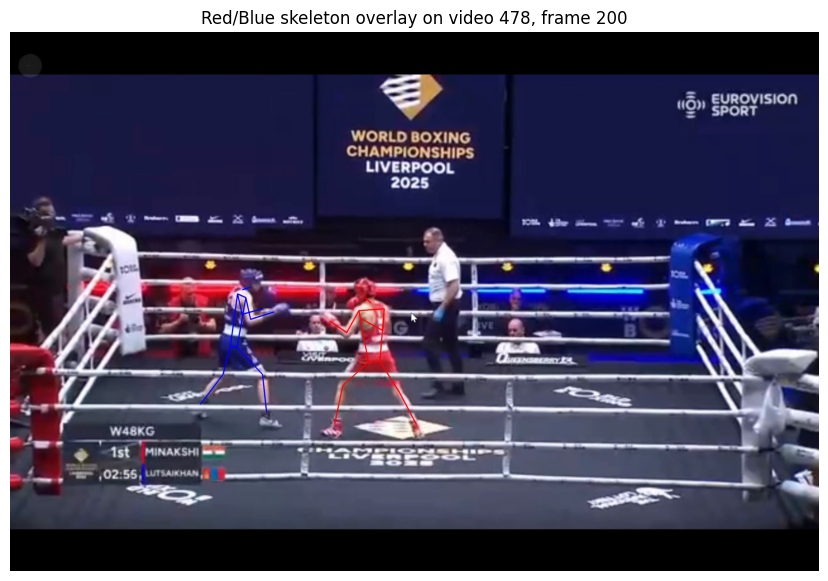

In [5]:
overlay_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
overlay_bgr = draw_pose_lines(overlay_bgr, red_xy, (0, 0, 255))
overlay_bgr = draw_pose_lines(overlay_bgr, blue_xy, (255, 0, 0))
overlay = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(overlay)
plt.title(f"Red/Blue skeleton overlay on video {VIDEO_ID}, frame {FRAME_INDEX}")
plt.axis("off")
plt.show()


In [6]:
segments = asr_payload.get("classified_segments", [])
print("First 10 commentary sentences")
for seg in segments[:10]:
    print({
        "start_time": seg.get("start_time"),
        "end_time": seg.get("end_time"),
        "class": seg.get("class"),
        "text": seg.get("text"),
    })


First 10 commentary sentences
{'start_time': 1.0, 'end_time': 4.739, 'class': 3, 'text': '48 kilogram final the light flyweight division'}
{'start_time': 6.041, 'end_time': 9.886, 'class': 3, 'text': 'yes we have again another southpaw against orthodox fighter'}
{'start_time': 10.567, 'end_time': 15.873, 'class': 2, 'text': 'southpaw against the rangy indian from that orthodox stance who started really well'}
{'start_time': 15.893, 'end_time': 19.678, 'class': 1, 'text': 'a couple of good straight shots to just settle things down from her point of view'}
{'start_time': 21.78, 'end_time': 24.483, 'class': 3, 'text': 'yeah i mean actually was really impressive yesterday at range'}
{'start_time': 24.984, 'end_time': 27.867, 'class': 3, 'text': 'obviously suited to her with those long limbs of hers'}
{'start_time': 28.008, 'end_time': 28.929, 'class': 3, 'text': "but that's whether"}
{'start_time': 29.069, 'end_time': 34.391, 'class': 2, 'text': "lucy can't and sort of close that distance 

In [7]:
events = event_payload if isinstance(event_payload, list) else (
    event_payload.get("events")
    or event_payload.get("event_list")
    or event_payload.get("video_events")
    or event_payload.get("results")
    or event_payload.get("predictions")
    or event_payload.get("data")
    or []
)

print("First 10 events")
for ev in events[:10]:
    print(ev)


First 10 events
{'distance': 'medium', 'effect': 'ineffective', 'foul': False, 'frame_begin': '97', 'frame_end': '104', 'left': '', 'name': 'punching', 'right': '', 'side': 'red', 'target': 'head', 'technique': 'rhook', 'type': 1, 'video_index': '', 'confidence_eff': 0.271}
{'distance': 'long', 'effect': 'ineffective', 'foul': False, 'frame_begin': '173', 'frame_end': '179', 'left': '', 'name': 'punching', 'right': '', 'side': 'blue', 'target': 'head', 'technique': 'rstraight', 'type': 1, 'video_index': '', 'confidence_eff': 0.057}
{'distance': 'long', 'effect': 'ineffective', 'foul': False, 'frame_begin': '211', 'frame_end': '219', 'left': '', 'name': 'punching', 'right': '', 'side': 'red', 'target': 'head', 'technique': 'lstraight', 'type': 1, 'video_index': '', 'confidence_eff': 0.059}
{'distance': 'long', 'effect': 'ineffective', 'foul': False, 'frame_begin': '215', 'frame_end': '225', 'left': '', 'name': 'punching', 'right': '', 'side': 'red', 'target': 'head', 'technique': 'rstra